# Breast cancer in the 2024 Nigeria Verbal and Social Autopsy (NVASA) study

This notebook explores IHME's copy of the NVASA microdata (DHS Program) and pulls out
what it says about breast cancer diagnosis, care-seeking, treatment, and death among
women of reproductive age.

The data are read directly from the J: drive and never modified. See `README.md` for
file locations and a summary of findings.

**Disclosure control.** Every table shown here passes through `nga_vasa.redact`, which
pools or masks unweighted cells below `nga_vasa.MIN_CELL` (5) and applies secondary
suppression to two-way tables. Histogram bins are merged until each holds at least five
deaths. Free-text narratives are not displayed unless `SHOW_NARRATIVES` is set locally.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nga_vasa as nv
from nga_vasa import redact, redact_crosstab

pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)

# Free-text narratives are microdata. Keep this False in committed outputs.
SHOW_NARRATIVES = False
print("small-cell threshold:", nv.MIN_CELL)

small-cell threshold: 5


In [2]:
df, meta = nv.load()
lab = nv.Labels(meta)
print(f"{df.shape[0]:,} deaths x {df.shape[1]:,} variables")
df["w"] = nv.weights(df)
print(f"weight sum = {df.w.sum():,.0f}; mean weight = {df.w.mean():.2f}")

4,879 deaths x 1,416 variables
weight sum = 5,019; mean weight = 1.03


## 1. What is in the file

Three questionnaire modules. The adult module is women aged 12–49 only: no men and no
women aged 50+. The sample combines deaths from NDHS-sampled households (`nsamp`=1) with
deaths found by screening extra households to boost maternal death counts (`nsamp`=2).

In [3]:
display(redact(lab.tab(df, "va1609t", df.w)))
display(redact(lab.tab(df, "nsamp")))
display(redact_crosstab(pd.crosstab(lab.decode(df, "va1609t"), lab.decode(df, "va1203"))))

,n,weighted_n
va1609t: Type of questionnaire,,
Adult,2269,2200.1
Child,1591,1775.3
Stillbirth/ neonatal,947,1043.1
<NA>,72,0.0


,n
nsamp: Source of sample (NDHS or screening),
NDHS survey,3275
NDHS screened households,1604


va1203,Female,Male
va1609t,,
<NA>,<5,<5
Adult,<5,<5
Child,808,783
Stillbirth/ neonatal,426,521


In [4]:
ad = nv.adults(df)
ad["age"] = pd.to_numeric(ad["vadagen"], errors="coerce")
ad["bc"] = nv.flag_breast_cancer(ad)
ad["denom"] = nv.analytic_denominator(ad, (15, 49))
print(f"adult module: {len(ad):,} deaths; official 15-49 denominator: {ad.denom.sum():,}")
ad["age"].describe().round(1)

adult module: 2,269 deaths; official 15-49 denominator: 607


count    2269.0
mean       32.0
std        10.8
min        12.0
25%        23.0
50%        32.0
75%        41.0
max        50.0
Name: age, dtype: float64

## 2. Causes of death among women 12–49

Cause of death is physician-certified verbal autopsy coded to ICD-11 (`vicd`), with a
broad grouping in `vallcod`. The main report's Figure 7.2 gives "Neoplasms 6%" for women
15–49 and does not break cancers out further.

In [5]:
redact(lab.tab(ad, "vallcod", ad.w))

,n,weighted_n
vallcod: All cause of death WRA,,
Infectious and parasitic diseases,757,730.0
"Pregnancy, childbirth and puerperium-related disorders",625,617.2
Diseases of the circulatory system,168,164.3
Cause of death unknown,139,125.6
Neoplasms,131,121.4
Road traffic or other transport accident,117,104.8
Non-communicable diseases,86,86.2
External causes of death,84,80.0
Gastrointestinal disorders,58,66.6


In [6]:
# Neoplasm deaths by ICD-11 code. 2C6x = malignant neoplasm of breast.
neo = ad[pd.to_numeric(ad["vallcod"], errors="coerce") == 7]
redact(neo["vicd"].value_counts()).rename("n").to_frame()

,n
vicd,
2C6Z,54
2E86.0,17
2D4Z,14
2D42,8
2F9Z,7
Other (each <5),31


## 3. Identifying breast cancer deaths

Three independent signals agree closely:

- physician-certified ICD-11 code beginning `2C6`
- the symptom question "Did she have any lump(s) and/or ulcer(s) in the breast?" (`a4157`)
- the health worker's stated cause of death, recorded as free text (`a4315`)

In [7]:
hw = ad["a4315"].astype(str).str.upper()
ad["hw_breast"] = hw.str.contains("BREAST|BREST")
print("ICD-11 breast cancer deaths:", ad.bc.sum())
display(redact_crosstab(pd.crosstab(ad.bc.rename("ICD breast cancer"), lab.decode(ad, "a4157").rename("breast lump/ulcer"))))
display(redact_crosstab(pd.crosstab(ad.bc.rename("ICD breast cancer"), lab.decode(ad, "a4310_10").rename("professional dx of cancer"))))
display(redact_crosstab(pd.crosstab(ad.bc.rename("ICD breast cancer"), ad.hw_breast.rename("health worker said breast"))))

ICD-11 breast cancer deaths: 58


breast lump/ulcer,Don't know,No,Yes
ICD breast cancer,,,
False,19,<5,<5
True,0,<5,<5


professional dx of cancer,<NA>,Don't know,No,Refused to answer,Yes
ICD breast cancer,,,,,
False,685,<5,<5,<5,48
True,7,<5,<5,0,46


health worker said breast,False,True
ICD breast cancer,,
False,<5,<5
True,<5,<5


In [8]:
# Health-worker free text among the ICD breast cancer deaths (small categories pooled)
redact(ad.loc[ad.bc, "a4315"].replace("", "<blank>").value_counts()).rename("n").to_frame()

,n
a4315,
<blank>,28
BREAST CANCER,11
CANCER OF THE BREAST,10
Other (each <5),9


## 4. How much of women's mortality is breast cancer?

Weighted shares, using the official denominator (NDHS-sampled households, death within
5 years of interview, women 15–49; N=607).

In [9]:
rows = []
for name, m in [("all adult module", ad.index == ad.index),
                ("official denominator, 15-49", ad.denom),
                ("official denominator, 12-49", nv.analytic_denominator(ad, (12, 49)))]:
    d = ad[m]
    rows.append({"population": name, "deaths": len(d), "breast_ca_n": int(d.bc.sum()),
                 "breast_ca_wtd_pct": round(nv.weighted_share(d, d.bc, d.w), 1),
                 "all_neoplasm_wtd_pct": round(nv.weighted_share(d, pd.to_numeric(d.vallcod, errors="coerce") == 7, d.w), 1)})
redact(pd.DataFrame(rows).set_index("population"))

,deaths,breast_ca_n,breast_ca_wtd_pct,all_neoplasm_wtd_pct
population,,,,
all adult module,2269,58,2.6,5.5
"official denominator, 15-49",607,18,2.7,5.7
"official denominator, 12-49",654,18,2.5,5.2


In [10]:
den = ad[ad.denom].copy()
den["age_band"] = pd.cut(den.age, [14, 24, 34, 49], labels=["15-24", "25-34", "35-49"])
def share_table(d, by):
    t = d.groupby(by, observed=True).apply(
        lambda x: pd.Series({"deaths": len(x), "breast_ca_n": int(x.bc.sum()),
                             "breast_ca_wtd_pct": round(nv.weighted_share(x, x.bc, x.w), 1)}))
    return redact(t, count_cols=["breast_ca_n"])
display(share_table(den, "age_band"))
display(share_table(den, lab.decode(den, "va1201e").rename("residence")))
display(share_table(den, den.va1201a.map(lambda z: "North" if z in (1, 2, 3) else "South").rename("region")))

,deaths,breast_ca_n,breast_ca_wtd_pct
age_band,,,
15-24,-,<5,-
25-34,166.0,5.0,2.1
35-49,271.0,11.0,4.1


,deaths,breast_ca_n,breast_ca_wtd_pct
residence,,,
Rural,365.0,10.0,3.1
Urban,242.0,8.0,2.2


,deaths,breast_ca_n,breast_ca_wtd_pct
region,,,
North,324.0,8.0,2.6
South,283.0,10.0,3.0


Zone-level and 5-year-age-band shares are not shown: with 18 breast cancer deaths in the
denominator every such cell falls below the disclosure threshold.

## 5. Diagnosis

Who was told it was cancer, how long the lump had been present, and how often the death
was certified or registered.

In [11]:
bc = ad[ad.bc].copy()
display(redact(bc["va1606y"].value_counts().sort_index()).rename("deaths by year of death").to_frame())
for v in ["a4310_10", "a4314", "a4351", "a4363", "a4004a", "a4002", "va1201e"]:
    display(redact(lab.tab(bc, v)))

,deaths by year of death
va1606y,
2020,6
2021,10
2022,18
2023,15
Other (each <5),7


,n
a4310_10: A health professional diagnosed cancer,
Yes,46
<NA>,7
No,<5
Don't know,<5


,n
a4314: Health worker told cause of death,
Yes,30
No,20
<NA>,7
Don't know,<5


,n
a4351: Medical certificate of cause of death issued,
No,45
Yes,9
Don't know,<5


,n
a4363: Had a death registration certificate,
No registration,51
Don't know,5
"Yes, certificate not seen",<5


,n
a4004a: Highest level of school,
Secondary,25
Higher,15
<NA>,10
Primary,8


,n
a4002: Marital status,
Married,43
Single,6
Widowed,5
Divorced/ separated,<5


,n
va1201e: Type of place of residence,
Urban,37
Rural,21


In [12]:
bc["lump_months"] = nv.duration_months(bc, "a4157u", "a4157n")
bc["illness_months"] = nv.duration_months(bc, "a4013u", "a4013n")
summary = bc[["lump_months", "illness_months"]].describe(percentiles=[.25, .5, .75]).round(1)
summary.loc["n >= 12 months"] = [(bc.lump_months >= 12).sum(), (bc.illness_months >= 12).sum()]
summary

,lump_months,illness_months
count,53.0,56.0
mean,8.6,11.9
std,10.5,19.6
min,0.1,0.2
25%,3.0,2.0
50%,6.0,6.0
75%,12.0,12.0
max,59.0,132.0
n >= 12 months,15.0,21.0


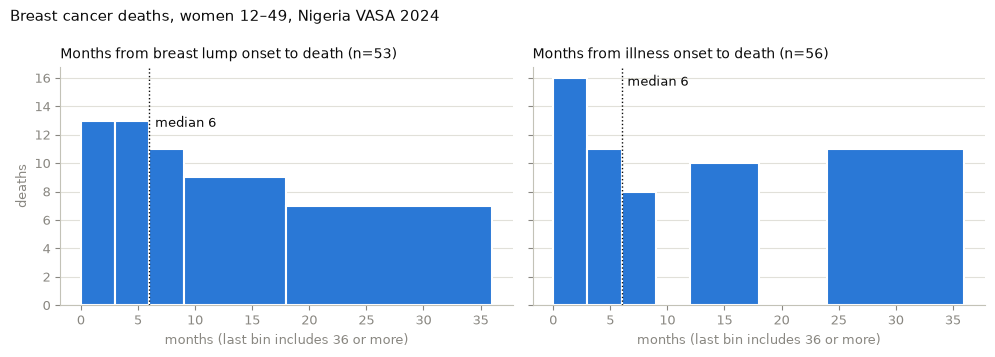

In [13]:
BLUE, INK, MUTED, GRID = "#2a78d6", "#0b0b0b", "#898781", "#e1e0d9"

def tidy(ax):
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    for s in ["left", "bottom"]:
        ax.spines[s].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, col, title in zip(axes, ["lump_months", "illness_months"],
                          ["Months from breast lump onset to death", "Months from illness onset to death"]):
    x = bc[col].dropna().clip(upper=36)
    counts, edges = nv.redact_bins(x, [0, 3, 6, 9, 12, 18, 24, 36.01])  # merged until each bin has >= 5 deaths
    ax.bar(edges[:-1], counts, width=np.diff(edges), align="edge", color=BLUE, edgecolor="white", linewidth=1.5)
    ax.set_title(f"{title} (n={len(x)})", fontsize=10, color=INK, loc="left")
    ax.set_xlabel("months (last bin includes 36 or more)", color=MUTED, fontsize=9)
    ax.axvline(x.median(), color=INK, linewidth=1, linestyle=":")
    ax.text(x.median() + 0.5, ax.get_ylim()[1] * 0.92, f"median {x.median():.0f}", fontsize=9, color=INK)
    tidy(ax)
axes[0].set_ylabel("deaths", color=MUTED, fontsize=9)
fig.suptitle("Breast cancer deaths, women 12–49, Nigeria VASA 2024", x=0.01, ha="left", fontsize=11, color=INK)
fig.tight_layout()
fig.savefig("fig1_durations.png", dpi=150, bbox_inches="tight")

## 6. Care-seeking pathway (social autopsy)

The social autopsy records up to nine care actions per death with the provider type at
each step (`a4252_2_1` … `a4252_2_9`), plus the first and last formal provider, referrals,
who decided, and problems reaching care.

In [14]:
seq = nv.provider_sequence(bc, lab)
first = seq.map(lambda s: s[0] if s else "No care sought")
ever = pd.Series([p for s in seq for p in set(s)]).value_counts()
print("first action not at a hospital:", seq.map(lambda s: bool(s) and "Hospital" not in s[0]).sum())
print("ever reached a hospital:", seq.map(lambda s: "Hospital" in s).sum())
print("ever used traditional/non-formal provider or drug seller:",
      seq.map(lambda s: any(("Traditional" in p) or ("Pharmacist" in p) for p in s)).sum())
first_r = redact(first.value_counts())
ever_r = redact(ever)
display(first_r.rename("first action").to_frame())
display(ever_r.rename("deaths with any use").to_frame())

first action not at a hospital: 28
ever reached a hospital: 42
ever used traditional/non-formal provider or drug seller: 18


,first action
Hospital,26
"Home care (own, relative, neighbor, friend)",10
Traditional or non-formal provider,7
Other (each <5),15


,deaths with any use
Hospital,42
Traditional or non-formal provider,16
"Home care (own, relative, neighbor, friend)",10
NGO or government clinic,6
Private doctor or clinic (formal/unsure),6
Other (each <5),6


In [15]:
for v in ["a4257", "a4261", "a4264", "a4253b", "a4254"]:
    display(redact(lab.tab(bc, v)))
print("Main problems accessing care (multiple response, among those reporting problems):")
display(redact(nv.count_letters(bc["a4255"], nv.PROBLEM_CODES)).rename("n").to_frame())

,n
a4257: Type of first provider taken to,
Government hospital,36
Private hospital,11
<NA>,7
Government health center,<5
Government health post,<5


,n
a4261: Referred to another health facility,
No,30
Yes,19
<NA>,7
Don't know,<5


,n
a4264: Left provider alive,
"Yes, left alive",35
"No, died at this provider",15
<NA>,7
Don't know,<5


,n
a4253b: Strongest voice in the decision,
Deceased?s spouse/partner,24
Deceased herself,13
Someone else,10
Deceased?s mother,<5
Deceased?s father,<5
Community elder/leader,<5
<NA>,<5
Compound head,<5


,n
a4254: Any problems accessing care,
No,31
Yes,26
Don't know,<5


Main problems accessing care (multiple response, among those reporting problems):


,n
H: Cost of health care,24
G: Cost of transportation,18
E: Too far to travel,14
F: No transportation available,6
Other (each <5),15


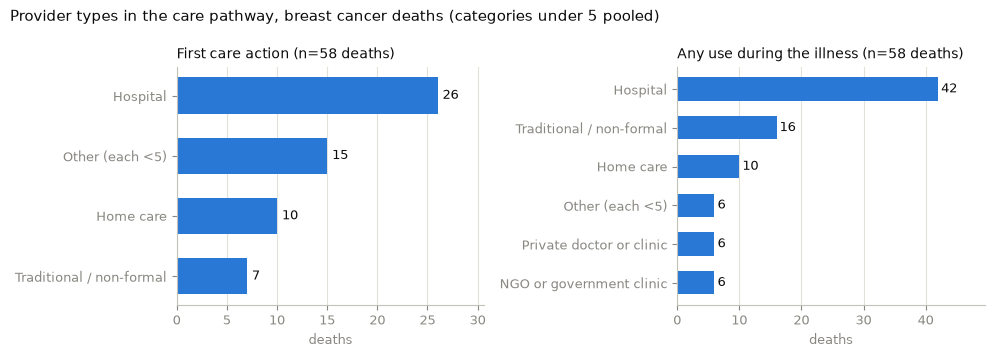

In [16]:
SHORT = {
    "Hospital": "Hospital",
    "Home care (own, relative, neighbor, friend)": "Home care",
    "Traditional or non-formal provider": "Traditional / non-formal",
    "Private doctor or clinic (formal/unsure)": "Private doctor or clinic",
    "NGO or government clinic": "NGO or government clinic",
    "Pharmacist or drug seller": "Pharmacist / drug seller",
    "Trained community health worker (CHW, nurse, or midwife)": "Community health worker",
    "No care sought": "No care sought",
}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, s, title in zip(axes, [first_r, ever_r],
                        ["First care action", "Any use during the illness"]):
    s = pd.to_numeric(s.rename(index=SHORT), errors="coerce").dropna().sort_values()
    ax.barh(s.index, s.values, color=BLUE, height=0.6)
    for y, v in enumerate(s.values):
        ax.text(v + 0.5, y, f"{v:.0f}", va="center", fontsize=9, color=INK)
    ax.set_title(f"{title} (n={len(bc)} deaths)", fontsize=10, color=INK, loc="left")
    ax.set_xlabel("deaths", color=MUTED, fontsize=9)
    ax.xaxis.grid(True, color=GRID, linewidth=0.8); ax.yaxis.grid(False)
    tidy(ax); ax.yaxis.grid(False)
    ax.set_xlim(0, s.max() * 1.18)
fig.suptitle("Provider types in the care pathway, breast cancer deaths (categories under 5 pooled)", x=0.01, ha="left", fontsize=11, color=INK)
fig.tight_layout()
fig.savefig("fig2_care_pathway.png", dpi=150, bbox_inches="tight")

## 7. Treatment

The treatment module asks about generic interventions only (fluids, transfusion,
antibiotics, an operation). There is no item for chemotherapy, radiotherapy, or hormonal
therapy, so cancer-specific treatment appears only in the free-text narrative.

In [17]:
for v in ["a4301", "a4302_2", "a4302_3", "a4302_5", "a4302_7", "a4303"]:
    display(redact(lab.tab(bc, v)))

,n
a4301: Received any treatment,
Yes,44
<NA>,7
No,6
Don't know,<5


,n
a4302_2: Received intravenous fluids treatment,
Yes,40
<NA>,14
No,<5
Don't know,<5


,n
a4302_3: Received a blood transfusion,
No,26
<NA>,14
Yes,14
Don't know,<5


,n
a4302_5: Received injectable antibiotics,
Yes,37
<NA>,14
Don't know,<5
No,<5


,n
a4302_7: Had operation for the illness,
No,27
Yes,15
<NA>,14
Don't know,<5


,n
a4303: Had an operation within 1 month before death,
<NA>,43
Yes,11
No,<5


In [18]:
narr = bc["a4471"].astype(str).str.upper()
keywords = {
    "chemotherapy": r"CHEMO",
    "radiotherapy": r"RADIO",
    "mastectomy / breast removed": r"MASTEC|REMOV|CUT",
    "operation / surgery": r"OPERAT|SURG",
    "fear / scared / refused": r"SCARED|AFRAID|FEAR|REFUS",
    "traditional / native": r"TRADITION|NATIVE|HERB",
    "money / afford / bills": r"MONEY|AFFORD|BILL|FUND|FOND",
    "late / stage / spread": r"LATE|STAGE|SPREAD|ON TIME",
    "no comment / nothing": r"^(NO|NOTHING|NON|NA|N|Y|NO COMMENT|NOTHING ELSE|NO OTHER SICKNESS)$",
}
hits = pd.Series({k: int(narr.str.contains(p, regex=True).sum()) for k, p in keywords.items()}, name="narratives")
redact(hits, other_label="Other themes (each <{k})").to_frame()

,narratives
radiotherapy,0
operation / surgery,7
no comment / nothing,32
Other themes (each <5),17


## 8. Narratives

Set `SHOW_NARRATIVES = True` at the top to print the free text for each breast cancer
death. They are short (median 12 characters) but a handful describe fear of mastectomy,
inability to pay, delay while using traditional medicine, and late detection.

In [19]:
if SHOW_NARRATIVES:
    cols = ["vadagen", "va1201a", "a4013n", "a4013u", "a4157n", "a4157u", "a4310_10", "a4302_7", "a4315", "a4471"]
    with pd.option_context("display.max_colwidth", 300):
        display(bc[cols].sort_values("vadagen"))
else:
    print(f"{len(bc)} narratives available; set SHOW_NARRATIVES = True to view them locally.")

58 narratives available; set SHOW_NARRATIVES = True to view them locally.


## 9. Limitations

- Small numbers: 58 breast cancer deaths in total, 18 in the representative denominator.
- Women aged 50 and older, who carry most breast cancer deaths, and men are not in the study.
- Treatment items are generic; cancer-specific care is visible only in short narratives.
- The professional-diagnosis question is skipped when no care was sought.
- Deaths date from 2018 to 2024, so recall reaches back up to six years.
- All records are deaths: no survival, stage, or case fatality.